# J–T correlation as a function of height

At each height, correlate the horizontal composite structures of J and T over the
full model domain, after subtracting their respective horizontal means:

$$r_{JT}(z)=\frac{\langle J'(x,z)T'(x,z)\rangle_x}
{\sqrt{\langle J'^2(x,z)\rangle_x\langle T'^2(x,z)\rangle_x}}.$$

The single plot compares NoRad and CldRad: **+1** means aligned structures,
**−1** means opposite structures, and **0** means no linear spatial correlation.
For single sinusoids, $r=\cos(\Delta\phi)$, so zero corresponds to a quarter-cycle
phase difference. For general structures, correlation also reflects shape differences
and does not determine the sign of a phase offset.

Each value compares J and T **at the same height**. Levels where either field's
horizontal RMS is less than 1% of its maximum over height are masked to avoid
interpreting nearly zero-amplitude structures.

In [6]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt

# Works from the notebook directory or the workspace root.
candidates = [q for parent in (Path.cwd(), *Path.cwd().parents)
              for q in (parent, parent / "KW_CRI")]
PROJECT_PATH = next((q for q in candidates
                     if (q / "File/NoRad_Composite.npz").is_file()), None)
if PROJECT_PATH is None:
    raise FileNotFoundError("Run from within Manuscript_Prep, or set PROJECT_PATH to KW_CRI.")
INPUT_PATH = PROJECT_PATH / "File"
FIGURE_PATH = PROJECT_PATH / "Figure/experiment_contrast"
FIGURE_PATH.mkdir(parents=True, exist_ok=True)

composites = {}
for name in ("NoRad", "CldRad"):
    with np.load(INPUT_PATH / f"{name}_Composite.npz", allow_pickle=False) as archive:
        composites[name] = {key: archive[key] for key in ("J", "T", "coord_x", "coord_z")}
norad_composite = composites["NoRad"]
cldrad_composite = composites["CldRad"]

In [7]:
MIN_RMS_FRACTION = 0.01


def correlation_by_height(composite, min_rms_fraction=MIN_RMS_FRACTION):
    """Zero-offset spatial correlation of J and T at each height."""
    J = np.asarray(composite["J"], dtype=float)
    T = np.asarray(composite["T"], dtype=float)
    x = np.asarray(composite["coord_x"], dtype=float)
    z = np.asarray(composite["coord_z"], dtype=float)
    if x.ndim != 1 or z.ndim != 1 or x.size < 2:
        raise ValueError("Expected 1-D coordinates with at least two horizontal points.")
    if J.shape != (z.size, x.size) or T.shape != J.shape:
        raise ValueError("J and T must have shape (height, horizontal position).")
    if not all(np.all(np.isfinite(a)) for a in (J, T, x, z)):
        raise ValueError("Fields and coordinates must be finite.")
    if not np.all(np.diff(z) > 0) or not np.all(np.diff(x) > 0):
        raise ValueError("Coordinates must increase strictly.")
    if not np.allclose(np.diff(x), np.diff(x)[0]):
        raise ValueError("Equal spatial weights require a uniform horizontal grid.")
    if not 0 <= min_rms_fraction < 1:
        raise ValueError("min_rms_fraction must lie in [0, 1).")

    J_prime = J - J.mean(axis=1, keepdims=True)
    T_prime = T - T.mean(axis=1, keepdims=True)
    J_rms = np.sqrt(np.mean(J_prime**2, axis=1))
    T_rms = np.sqrt(np.mean(T_prime**2, axis=1))
    valid = ((J_rms > min_rms_fraction * J_rms.max())
             & (T_rms > min_rms_fraction * T_rms.max()))
    covariance = np.mean(J_prime * T_prime, axis=1)
    correlation = np.divide(covariance, J_rms * T_rms,
                            out=np.full(z.size, np.nan), where=valid)
    return np.clip(correlation, -1.0, 1.0)


correlations = {name: correlation_by_height(data)
                for name, data in composites.items()}

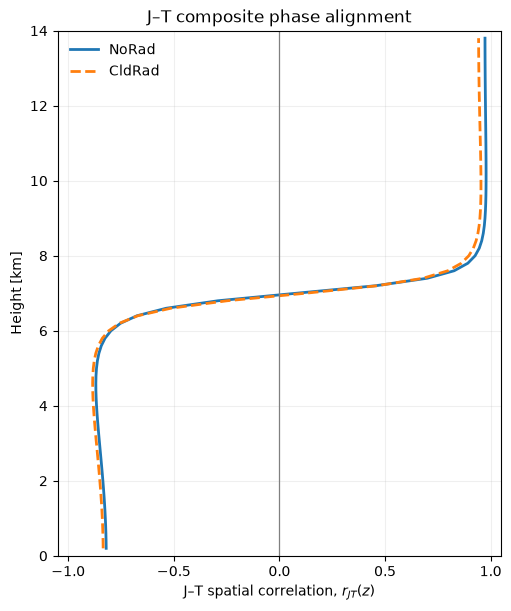

In [8]:
fig, ax = plt.subplots(figsize=(5, 6), constrained_layout=True)
for name, color, linestyle in [("NoRad", "tab:blue", "-"),
                                ("CldRad", "tab:orange", "--")]:
    ax.plot(correlations[name], composites[name]["coord_z"] / 1000,
            color=color, linestyle=linestyle, linewidth=2, label=name)

ax.axvline(0, color="0.5", linewidth=0.9)
ax.set(xlabel=r"J–T spatial correlation, $r_{JT}(z)$",
       ylabel="Height [km]", title="J–T composite phase alignment",
       xlim=(-1.05, 1.05), xticks=[-1, -0.5, 0, 0.5, 1])
ax.set_ylim(min(data["coord_z"].min() for data in composites.values()) / 1000,
            max(data["coord_z"].max() for data in composites.values()) / 1000)
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.savefig(FIGURE_PATH / "JT_correlation_by_height.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)